## Rotação de Imagens com OpenCV

Nesta etapa, será estudada uma das transformações geométricas mais básicas aplicadas a imagens digitais: a **rotação**.

A rotação faz parte do conjunto de **transformações afins**, que permitem alterar geometricamente uma imagem preservando características como linhas retas e relações de paralelismo.

Para realizar essa operação com a biblioteca **OpenCV**, o processo será dividido nas seguintes etapas:

1. **Importação das bibliotecas:** serão carregados o OpenCV e a função específica utilizada pelo Google Colab para exibir imagens.

2. **Carregamento da imagem:** a imagem que será processada será lida utilizando a função `cv2.imread()`.

3. **Obtenção das dimensões da imagem:** serão identificadas a altura e a largura da imagem para determinar seu ponto central.

4. **Definição do centro de rotação:** o centro da imagem será utilizado como referência para realizar a rotação.

5. **Criação da matriz de rotação:** a função `cv2.getRotationMatrix2D()` será utilizada para gerar a matriz responsável pela transformação geométrica.

6. **Aplicação da rotação:** a função `cv2.warpAffine()` aplicará a transformação definida pela matriz de rotação sobre a imagem original.

7. **Visualização do resultado:** serão exibidas tanto a imagem original quanto a imagem após a rotação.

8. **Salvamento da imagem:** por fim, a imagem rotacionada será salva como um novo arquivo.

Neste exemplo, a imagem será rotacionada em **45 graus**, mantendo sua escala original.



Saving image.png to image (1).png
Imagem original:


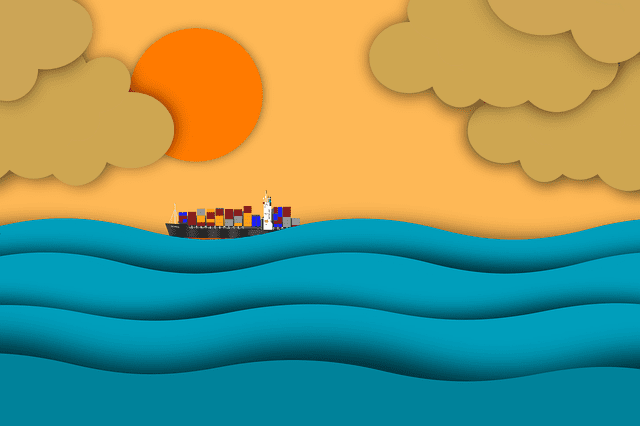

Imagem rotacionada:


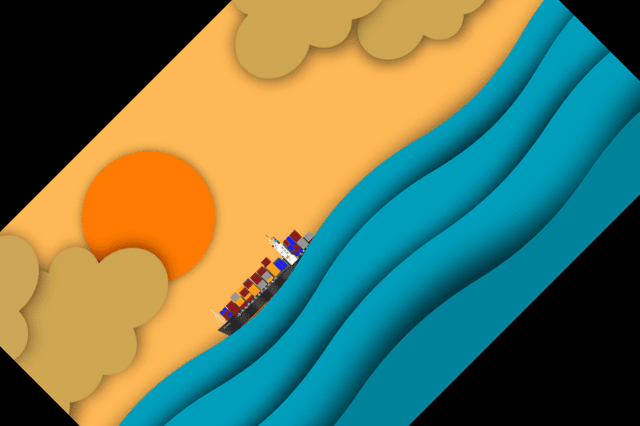

True

In [5]:
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

# Upload e leitura da imagem
uploaded = files.upload()
filename = next(iter(uploaded))
image = cv2.imread(filename)

# Dimensões e centro da imagem
height, width = image.shape[:2]
center = (width / 2, height / 2)

# Matriz de rotação
rotate_matrix = cv2.getRotationMatrix2D(
    center=center,
    angle=45,
    scale=1
)

# Aplicação da rotação
rotated_image = cv2.warpAffine(
    image,
    rotate_matrix,
    (width, height)
)

# Exibição das imagens
print("Imagem original:")
cv2_imshow(image)

print("Imagem rotacionada:")
cv2_imshow(rotated_image)

# Salvamento
cv2.imwrite("rotated_image.jpg", rotated_image)

### Translação da Imagem

Nesta etapa, o deslocamento da imagem foi definido com base nas suas próprias dimensões. Para isso, foram utilizados os valores `tx = width / 4` e `ty = height / 4`.

Isso significa que a imagem será deslocada em 1/4 da sua largura para a direita e 1/4 da sua altura para baixo.

Esses valores são inseridos em uma matriz de translação, criada com o NumPy. Essa matriz informa ao OpenCV quanto a imagem deve se mover em cada direção.

Depois, a função `cv2.warpAffine()` aplica a matriz sobre a imagem original, gerando a imagem transladada. Como as dimensões da imagem são mantidas, as partes que ultrapassam seus limites após o deslocamento são cortadas.

### Observações

* `tx` representa o deslocamento no eixo **x** (horizontal).
* `ty` representa o deslocamento no eixo **y** (vertical).
* Valores positivos de `tx` movem a imagem para a **direita**.
* Valores positivos de `ty` movem a imagem para **baixo**.
* A função `warpAffine()` é responsável por aplicar a transformação.


Saving image.png to image (3).png
Imagem original:


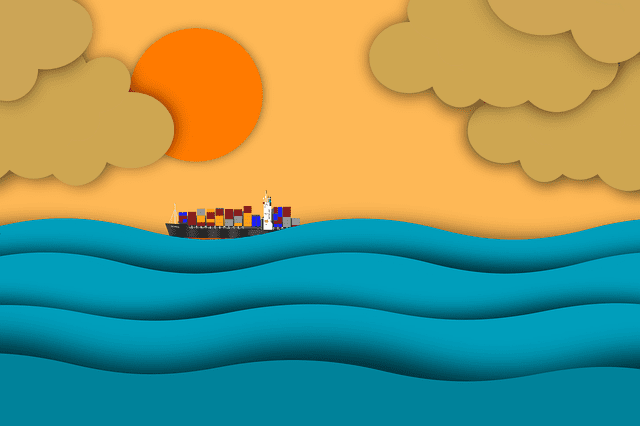

Imagem transladada:


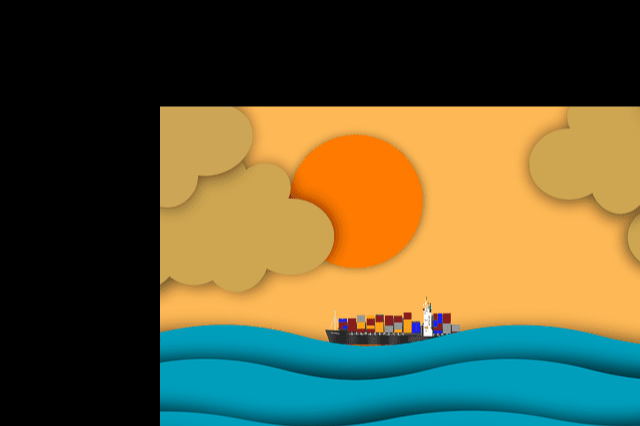

True

In [7]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

# Upload e leitura da imagem
uploaded = files.upload()
filename = next(iter(uploaded))
image = cv2.imread(filename)

# Dimensões da imagem
height, width = image.shape[:2]

# Valores de deslocamento
tx = width / 4
ty = height / 4

# Matriz de translação
translation_matrix = np.array([
    [1, 0, tx],
    [0, 1, ty]
], dtype=np.float32)

# Aplicação da translação
translated_image = cv2.warpAffine(
    image,
    translation_matrix,
    (width, height)
)

# Exibição das imagens
print("Imagem original:")
cv2_imshow(image)

print("Imagem transladada:")
cv2_imshow(translated_image)

# Salvamento da imagem
cv2.imwrite("translated_image.jpg", translated_image)